# 1. How to load the shipped model and run an experiment

#### 1.0 Overview
This notebook shows how to use the pre-trained ML model `heston_30d_alpha_50` that ships with the repository. It hedges a European call in a simulated Heston market by trading a stock and a variance swap. No training is necessary, the model is ready to use.

Why this matters: you reproduce the reference experiment of the Deep Hedging paper without any computation of your own, while you can test the model on any number of new market scenarios.

#### 1.1. Market design, sampling and architecture of ML model `heston_30d_alpha_50`

The ML model `heston_30d_alpha_50` was trained on the same settings of the Deep Hedging paper https://arxiv.org/html/1802.03042v1#S5, which are:

**Heston market**:
- $S^1_0 = 100$ (spot at $t=0$)
- $v_0 = 0.04$ (initial variance at $t=0$)
- $\kappa = 1.0$ (mean reversion speed)
- $\theta = 0.04$ (long-run variance)
- $\xi = 2.0$ (vol-of-vol)
- $\rho = -0.7$ (correlation)
- $r = 0$ (zero interest across all timesteps)
- No transaction costs $\text{Cost}_T(\delta) = 0$, for trading in the stock or variance (variance swap)

**Two hedging instruments $S_t^1$ and $V_t$ (or $S_t^2$)**: 
- A stock $S_t^1$ driven by a Wiener process $dS_t^1 = \sqrt{V_t}\, S_t^1\, dW_t^1$
- A variance $V_t$ driven by CIR process $dV_t = \kappa(\theta - V_t)\, dt + \xi \sqrt{V_t}\, dW_t$ (or variance swap $S_t^2 := \int_0^t V_s\, ds + \frac{V_t - \theta}{\kappa}\left(1 - e^{-\kappa(T-t)}\right) + \theta\,(T-t)$ to make the variance tradable)

**A European call $C_t$:**
- Payoff at maturity $Z := \max(S_T^1 - K, 0)$ 
- Strike given by $K = 100$   

**Time discretization**
- $t_i=\frac{i}{365}$ for $i=0,..,30$ and $dt = \frac{1}{365}$ (stepsize)
- $T = 30/365$ (maturity)

**Premium calculation at $t=0$:**
- The premium $p_0$ (or $q$) is computed via Fang-Oosterlee for $N = 256$ terms at $(S_0, v_0)$ with maturity $T$ (no Monte Carlo used!)

**Simulation of hedging instruments and computation of analytical deltas:**
- Variance $V_t$ is exactly sampled from the CIR transition density (noncentral $\chi^2$)
- Stock path $S_t^1$ sampled by simplified Broadie-Kaya scheme (no Euler scheme!), conditioned on exact variance path
- Variance swap path $S_t^2$ computed from variance path via $S^2_k = \int_0^{t_k} V_s\, ds + L(t_k, V_k)$ by trapezoidal rule 
- Random draws in fixed order (variance first, then $Z$), one seed per dataset ⇒ bit-identical paths

- The analytical deltas $\delta^1_t = \frac{\partial u}{\partial s}$ and $\delta^2_t = \frac{\partial u / \partial v}{\partial L(t,V_t) / \partial v}$ are computed via Fang-Oosterlee

**The ML model**:
- The ML model is built in TensorFlow using the Sequential API
- The ML model is a computational graph, that estimates via DFNNs at **each rebalancing step** deltas to minimize the OCE of the CVaR-loss on the terminal hedging error
- For each rebalancing step exists a DFNN (30 networks), specified by:
  - Input layer with $2$ neurons that receives $(\log S_k^1, V_k)$ log-stock and variance
  - One hidden layer with $17$ neurons
  - Another hidden layer with $17$ neurons
  - Output layer with $2$ neurons providing hedge positions $\delta^1_k$, $\delta^2_k$ for stock and variance swap
  - Activation across all layers is ReLU
  - BatchNormalization is applied **BEFORE** every ReLU activation
- Training: 
  - Initialization by Glorot uniform (Keras default)
  - TensorFlow random number seed set to $42$ for reproducibility 
  - OCE threshold starts at $w = 0$ 
  - The Loss function is $J:= w + \mathbb{E}\left[\max(L - w, 0)\right] / (1 - \alpha)$ (OCE formula of CVaR), with $\alpha = 0.5$ as CVaR risk level 
  - Optimizer is Adam 
  - Learning rate set to $0.005$
  - Batch size is $256$
  - Gradient steps are $200000$ 
  - Training size is $100000$ paths (with seed 15)
  - Validation size is $100000$ (with seed 25, basis of the $J(\text{val})$ curve)
  - Out-of-sample testset is $1000000$ paths (with seed 35, only used after training for evaluation)

#### 1.2. How to run experiments and test the ML model `heston_30d_alpha_50`

Four steps: import the package, load the model, run experiment, read the charts.

0. **Import the package**
    - Make sure you installed the package via `pip install`. 
    - Make sure the notebook is in the same path as the loaded package.
    - Import inside the notebook the `DeepHedger` class via `from deep_hedging_heston import DeepHedger`.

In [ ]:
from deep_hedging_heston import DeepHedger  # import the class DeepHedger from package deep_hedging_heston 

1. **Load the model:** 
    - Use command `DeepHedger.load_model("folderpath", "ml_model_name")`, which takes arguments `folderpath` as path to repository root and `ml_model_name` as the model name. 
    - The loader reads the parameter file `ml_models/heston_30d_alpha_50_parameters.json` (settings and learning curve), the checkpoint files `ml_models/heston_30d_alpha_50-1.index` and `ml_models/heston_30d_alpha_50-1.data-00000-of-00001` (network weights, OCE threshold $w$, BatchNorm statistics) and returns a ready-to-use `DeepHedger` object.

In [9]:
my_model = DeepHedger.load_model("/Users/hb/Desktop/Python/deep-hedging-heston/ml_models", "heston_30d_alpha_50") # load the model providing folderpath and model name

2. **Run an experiment and correctly read the chart:**
    - Use command `my_experiment_name.experiment(seed)`, where `seed` is a non-negative integer which generates the market scenario. Same seed generates same scenario, a new seed generates a new scenario. The seed=4 reproduces our reference result, with terminal errors of $-1.0672$ (analytical) and $-1.0272$ (ML model). 
    - Try several seeds to experiment with the pre-shipped ML model, to see if the ML-hedge stays close to the analytical benchmark, on new unseen paths.
    - Row 1 plots for each day the stock $S_t^1$ and variance $V_t$, to show the "to-be-hedged" market scenario.
    - Row 2 plots for each day the two hedging strategies $\delta_t^1$ (stock) and $\delta_t^2$ (variance swap) for the ML model (orange) and analytical solution (blue, Fang-Oosterlee).
    - Row 3 plots for each day the PnL and portfolio for the ML model (orange) and analytical solution (blue).
    - Row 4 plots at left a bar chart of terminal hedging error for the ML model (orange) and analytical solution (blue). At the right it plots the learning curves of training and validation, for the preshipped model.

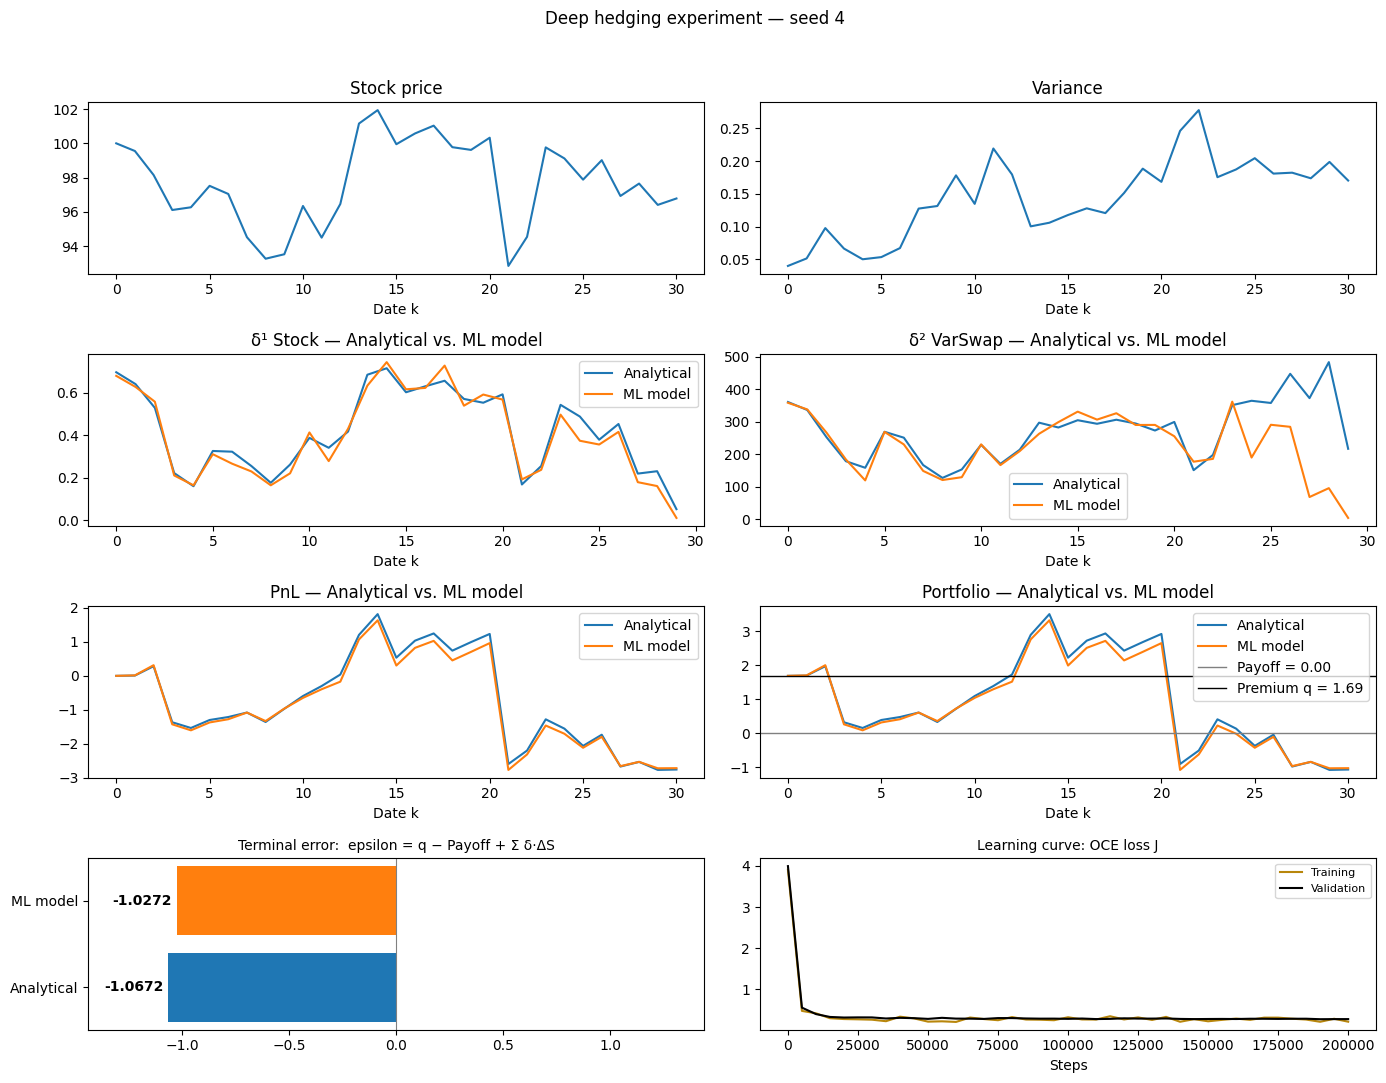

Terminal error — formula: -1.0672 | ML model: -1.0272


{'figure': <Figure size 1400x1100 with 8 Axes>,
 'eps_formula': -1.0672226722144846,
 'eps_ml': -1.0271626533897824}

In [ ]:
my_model.experiment(seed=4)   # run the experiment on reference seed 4, to reproduce the reference result (terminal errors -1.0672 analytical / -1.0272 ML)

3. **Change the seed to run a new exeperiment on unseen scenarios:**
- Change the seed to a new integer and see whether the ML hedge stays close to analytical hedge for the new scenario.

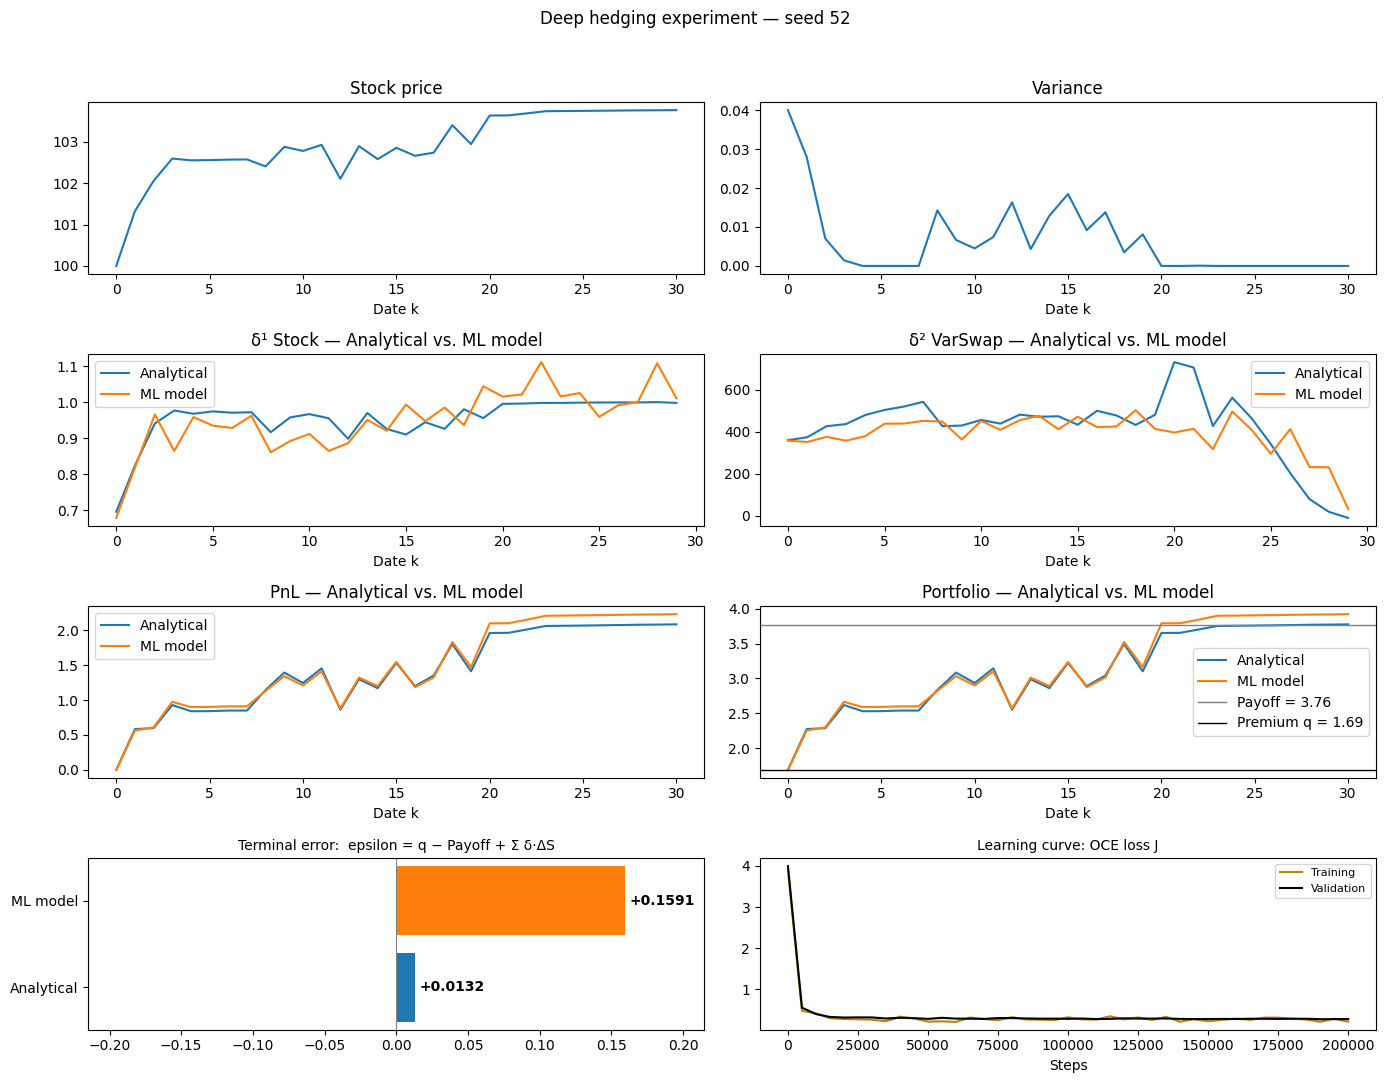

Terminal error — formula: +0.0132 | ML model: +0.1591


{'figure': <Figure size 1400x1100 with 8 Axes>,
 'eps_formula': 0.013176373086754012,
 'eps_ml': 0.15913955330496288}

In [ ]:
my_model.experiment(seed=52)  # run the experiment on a NEW seed to generate an new market path, to check if the hedge stays robust in a new scenario